# Notebook 18: Block number significance by digit

**Question:** Is 4 the only block digit with a significant price effect? Does 8 in a block number help?

**Approach:** For each digit 0-9, create `block_has_X` (does the block number contain digit X?). Test each in the full model, first with town fixed effects, then with street-level fixed effects to control for micro-location within a town.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/hdb_analysis.csv')
print(f'Loaded {len(df):,} transactions')

# Extract numeric part of block
df['block_num_str'] = df['block'].astype(str).str.replace('[A-Za-z]', '', regex=True)

# For each digit 0-9: does the block number contain this digit?
for d in range(10):
    df[f'block_has_{d}'] = df['block_num_str'].str.contains(str(d)).astype(int)

# Prevalence
print('\nBlock digit prevalence:')
for d in range(10):
    n = df[f'block_has_{d}'].sum()
    print(f'  Contains {d}: {n:,} ({n/len(df)*100:.1f}%)')

# Derived
df['remaining_lease_sq'] = df['remaining_lease_years'] ** 2
df.to_csv('data/nb18_block_digit.csv', index=False)
print('\nSaved for R')

Loaded 51,748 transactions

Block digit prevalence:
  Contains 0: 11,602 (22.4%)
  Contains 1: 19,058 (36.8%)
  Contains 2: 16,583 (32.0%)
  Contains 3: 14,407 (27.8%)
  Contains 4: 14,504 (28.0%)
  Contains 5: 12,392 (23.9%)
  Contains 6: 14,181 (27.4%)
  Contains 7: 10,618 (20.5%)
  Contains 8: 10,774 (20.8%)
  Contains 9: 8,424 (16.3%)



Saved for R


## Test 1: Town-level fixed effects

Same specification as the main model — controls for town (26 categories) but not street.

In [2]:
%%script Rscript -

library(lmtest)
library(sandwich)

df <- read.csv('data/nb18_block_digit.csv')
df$town <- as.factor(df$town)
df$flat_type <- as.factor(df$flat_type)
df$flat_model_grouped <- as.factor(df$flat_model_grouped)
df$month_factor <- as.factor(df$month)
df$remaining_lease_sq <- df$remaining_lease_years^2

base <- resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
    remaining_lease_years + remaining_lease_sq + flat_model_grouped +
    dist_cbd_km + mrt_dist_m + hawker_dist_m + popular_school_dist_m +
    park_dist_m + hospital_dist_m + columbarium_dist_m + temple_dist_m +
    coast_dist_m + num_eights_tail + month_factor

cat('\n=== block_has_X with TOWN fixed effects ===\n\n')
cat(sprintf('%5s  %10s  %8s  %12s  %s\n', 'Digit', 'Coef ($)', 'SE', 'p-value', 'Sig'))
cat(paste0(rep('-', 55), collapse=''), '\n')

results <- data.frame()
for (d in 0:9) {
    vn <- paste0('block_has_', d)
    m <- lm(update(base, paste('~ . +', vn)), data=df)
    ct <- coeftest(m, vcov=vcovHC(m, type='HC1'))
    i <- which(rownames(ct) == vn)
    co <- ct[i,1]; se <- ct[i,2]; pv <- ct[i,4]
    sg <- ifelse(pv<0.001,'***',ifelse(pv<0.01,'**',ifelse(pv<0.05,'*','')))
    cat(sprintf('%5d  %10.0f  %8.0f  %12.6f  %s\n', d, co, se, pv, sg))
    results <- rbind(results, data.frame(digit=d, coef=co, se=se, p=pv,
        ci_lo=co-1.96*se, ci_hi=co+1.96*se, model='Town FE'))
}
write.csv(results, 'data/nb18_town_fe.csv', row.names=FALSE)

Loading required package: zoo



Attaching package: ‘zoo’



The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




=== block_has_X with TOWN fixed effects ===

Digit    Coef ($)        SE       p-value  Sig


------------------------------------------------------- 


...

    5       -3836       651      0.000000  ***


    6       -6205       634      0.000000  ***


    7       -4890       697      0.000000  ***


    8        2131       698      0.002270  **


    9       -5227       766      0.000000  ***


## Test 2: Street-level fixed effects

Controls for the specific street (570 streets), not just the town. This means we're comparing blocks on the *same street* — e.g. Block 404 vs Block 405 on Ang Mo Kio Avenue 10.

In [3]:
%%script Rscript -

library(lmtest)
library(sandwich)

df <- read.csv('data/nb18_block_digit.csv')
df$street_name <- as.factor(df$street_name)
df$flat_type <- as.factor(df$flat_type)
df$flat_model_grouped <- as.factor(df$flat_model_grouped)
df$month_factor <- as.factor(df$month)
df$remaining_lease_sq <- df$remaining_lease_years^2

# Street-level FE — drop dist_cbd_km (absorbed by street FE)
base <- resale_price ~ street_name + flat_type + floor_area_sqm + storey_mid +
    remaining_lease_years + remaining_lease_sq + flat_model_grouped +
    mrt_dist_m + hawker_dist_m + popular_school_dist_m +
    park_dist_m + hospital_dist_m + columbarium_dist_m + temple_dist_m +
    coast_dist_m + num_eights_tail + month_factor

cat('\n=== block_has_X with STREET-LEVEL fixed effects ===\n\n')
cat(sprintf('%5s  %10s  %8s  %12s  %s\n', 'Digit', 'Coef ($)', 'SE', 'p-value', 'Sig'))
cat(paste0(rep('-', 55), collapse=''), '\n')

results <- data.frame()
for (d in 0:9) {
    vn <- paste0('block_has_', d)
    m <- lm(update(base, paste('~ . +', vn)), data=df)
    ct <- coeftest(m, vcov=vcovHC(m, type='HC1'))
    i <- which(rownames(ct) == vn)
    co <- ct[i,1]; se <- ct[i,2]; pv <- ct[i,4]
    sg <- ifelse(pv<0.001,'***',ifelse(pv<0.01,'**',ifelse(pv<0.05,'*','')))
    cat(sprintf('%5d  %10.0f  %8.0f  %12.6f  %s\n', d, co, se, pv, sg))
    results <- rbind(results, data.frame(digit=d, coef=co, se=se, p=pv,
        ci_lo=co-1.96*se, ci_hi=co+1.96*se, model='Street FE'))
}
write.csv(results, 'data/nb18_street_fe.csv', row.names=FALSE)

Loading required package: zoo



Attaching package: ‘zoo’



The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




=== block_has_X with STREET-LEVEL fixed effects ===

Digit    Coef ($)        SE       p-value  Sig


------------------------------------------------------- 


...

(s) 12049, 26087
8: In meatHC(x, type = type, omega = omega) :
  HC1 covariances become (close to) s

ingular if hat values are (close to) 1 as for observation(s) 12049, 26087
9: In meatHC(x, type = typ

e, omega = omega) :
  HC1 covariances become (close to) singular if hat values are (close to) 1 as f

or observation(s) 12049, 26087
10: In meatHC(x, type = type, omega = omega) :
  HC1 covariances beco

me (close to) singular if hat values are (close to) 1 as for observation(s) 12049, 26087


## Chart: Side-by-side comparison

Town FE vs Street FE — which digits survive the tighter control?

Saved: data/block_digit_significance.svg + .png


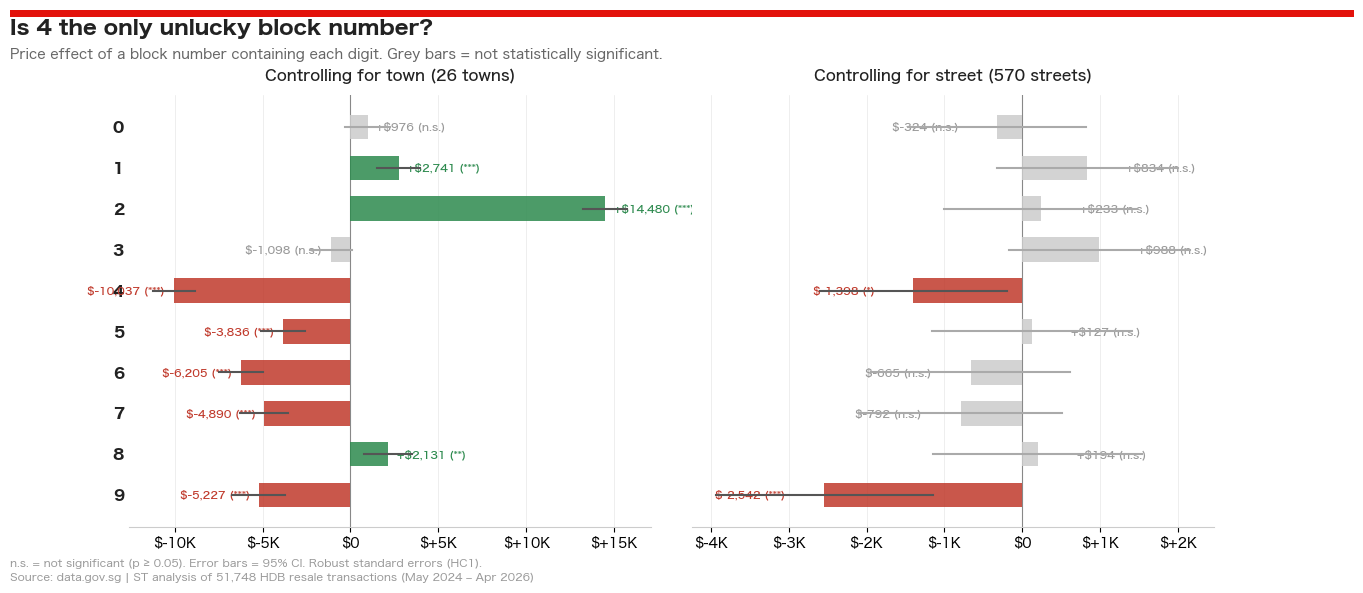

In [4]:
import matplotlib
matplotlib.rcParams['font.family'] = ['Hiragino Sans', 'Arial Unicode MS', 'sans-serif']
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

town = pd.read_csv('data/nb18_town_fe.csv')
street = pd.read_csv('data/nb18_street_fe.csv')

DARK = '#222222'
MID = '#666666'
LIGHT = '#999999'
RED = '#c0392b'
GREEN = '#2d8a4e'
GREY_BAR = '#cccccc'

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.patch.set_facecolor('white')

for ax, data, title in zip(axes, [town, street], 
                            ['Controlling for town (26 towns)', 
                             'Controlling for street (570 streets)']):
    ax.set_facecolor('white')
    
    colors = []
    for _, row in data.iterrows():
        if row['p'] >= 0.05:
            colors.append(GREY_BAR)
        elif row['coef'] < 0:
            colors.append(RED)
        else:
            colors.append(GREEN)
    
    y_pos = list(range(9, -1, -1))
    
    ax.barh(y_pos, data['coef'].values, height=0.6, color=colors, alpha=0.85, zorder=3)
    
    # CI
    for y, lo, hi, c in zip(y_pos, data['ci_lo'], data['ci_hi'], colors):
        ax.plot([lo, hi], [y, y], color='#555' if c != GREY_BAR else '#aaa',
                linewidth=1.5, zorder=4)
    
    ax.axvline(0, color='#888', linewidth=0.8, zorder=2)
    
    # Value labels
    for y, row_idx in zip(y_pos, range(len(data))):
        row = data.iloc[row_idx]
        p = row['p']
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        prefix = '+' if row['coef'] > 0 else ''
        label = f'{prefix}${row["coef"]:,.0f} ({sig})'
        offset = 500 if row['coef'] >= 0 else -500
        ha = 'left' if row['coef'] >= 0 else 'right'
        tc = colors[row_idx] if colors[row_idx] != GREY_BAR else LIGHT
        ax.text(row['coef'] + offset, y, label, fontsize=8, color=tc,
                ha=ha, va='center', fontweight='medium')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels([str(d) for d in range(10)], fontsize=11, fontweight='bold', color=DARK)
    ax.set_title(title, fontsize=11, fontweight='medium', color=DARK, pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#ccc')
    ax.tick_params(axis='y', length=0)
    ax.xaxis.grid(True, color='#e8e8e8', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(
        lambda x, _: f'${x/1000:+,.0f}K' if x != 0 else '$0'))

# Red top bar
fig.patches.append(plt.Rectangle(
    (0.04, 0.95), 0.96, 0.012,
    transform=fig.transFigure, facecolor='#e3120b',
    edgecolor='none', clip_on=False))

fig.text(0.04, 0.92,
         'Is 4 the only unlucky block number?',
         fontsize=15, fontweight='bold', color=DARK, ha='left')
fig.text(0.04, 0.88,
         'Price effect of a block number containing each digit. Grey bars = not statistically significant.',
         fontsize=10, color=MID, ha='left')

fig.text(0.04, 0.01,
         'n.s. = not significant (p \u2265 0.05). Error bars = 95% CI. Robust standard errors (HC1).\n'
         'Source: data.gov.sg | ST analysis of 51,748 HDB resale transactions (May 2024 \u2013 Apr 2026)',
         fontsize=8, color=LIGHT, ha='left', linespacing=1.5)

plt.subplots_adjust(top=0.82, bottom=0.10, wspace=0.08)
fig.savefig('data/block_digit_significance.svg', bbox_inches='tight', facecolor='white')
fig.savefig('data/block_digit_significance.png', dpi=200, bbox_inches='tight', facecolor='white')
print('Saved: data/block_digit_significance.svg + .png')
plt.show()

## Summary

Compare what survives when we tighten controls from 26 towns to 570 streets.

In [5]:
import pandas as pd
town = pd.read_csv('data/nb18_town_fe.csv')
street = pd.read_csv('data/nb18_street_fe.csv')

print('\n=== Which digits survive street-level controls? ===\n')
print(f'{"Digit":>5}  {"Town FE":>12}  {"Street FE":>12}  Change')
print('-' * 50)
for d in range(10):
    t = town[town['digit'] == d].iloc[0]
    s = street[street['digit'] == d].iloc[0]
    t_sig = '***' if t['p'] < 0.001 else '**' if t['p'] < 0.01 else '*' if t['p'] < 0.05 else 'n.s.'
    s_sig = '***' if s['p'] < 0.001 else '**' if s['p'] < 0.01 else '*' if s['p'] < 0.05 else 'n.s.'
    change = 'SURVIVES' if s['p'] < 0.05 else 'DROPS OUT' if t['p'] < 0.05 else 'never sig'
    print(f'{d:>5}  ${t["coef"]:>10,.0f} {t_sig:>3}  ${s["coef"]:>10,.0f} {s_sig:>3}  {change}')


=== Which digits survive street-level controls? ===

Digit       Town FE     Street FE  Change
--------------------------------------------------
    0  $       976 n.s.  $      -324 n.s.  never sig
    1  $     2,741 ***  $       834 n.s.  DROPS OUT
    2  $    14,480 ***  $       233 n.s.  DROPS OUT
    3  $    -1,098 n.s.  $       988 n.s.  never sig
    4  $   -10,037 ***  $    -1,398   *  SURVIVES
    5  $    -3,836 ***  $       127 n.s.  DROPS OUT
    6  $    -6,205 ***  $      -665 n.s.  DROPS OUT
    7  $    -4,890 ***  $      -792 n.s.  DROPS OUT
    8  $     2,131  **  $       194 n.s.  DROPS OUT
    9  $    -5,227 ***  $    -2,542 ***  SURVIVES
